In [ ]:
#1. DATA LOADER (MNIST / Fashion-MNIST)

In [1]:
import numpy as np
import gzip, os, urllib.request

BASE_URL = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"

FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz"
}

def download():
    os.makedirs("data", exist_ok=True)
    for name, f in FILES.items():
        path = "data/" + f
        if not os.path.exists(path):
            urllib.request.urlretrieve(BASE_URL + f, path)

def load_images(path):
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28*28) / 255.0

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=8)

download()
X_train = load_images("data/" + FILES["train_images"])
y_train = load_labels("data/" + FILES["train_labels"])
X_test = load_images("data/" + FILES["test_images"])
y_test = load_labels("data/" + FILES["test_labels"])

In [ ]:
#2. ACTIVATIONS + UTILITIES

In [2]:
def relu(x): return np.maximum(0, x)
def drelu(x): return (x > 0).astype(float)

def sigmoid(x): return 1/(1+np.exp(-x))
def dsigmoid(x): s = sigmoid(x); return s*(1-s)

def tanh(x): return np.tanh(x)
def dtanh(x): return 1-np.tanh(x)**2

def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def onehot(y, num=10):
    o = np.zeros((len(y), num))
    o[np.arange(len(y)), y] = 1
    return o

In [ ]:
#3. MLP FROM SCRATCH

In [3]:
class MLP:
    def __init__(self, inp, hid, out, lr=0.1, act="relu"):
        self.W1 = np.random.randn(inp, hid)*0.01
        self.b1 = np.zeros((1, hid))
        self.W2 = np.random.randn(hid, out)*0.01
        self.b2 = np.zeros((1, out))
        self.lr = lr
        self.act = act

    def activation(self, x):
        if self.act=="relu": return relu(x)
        if self.act=="sigmoid": return sigmoid(x)
        if self.act=="tanh": return tanh(x)

    def dactivation(self, x):
        if self.act=="relu": return drelu(x)
        if self.act=="sigmoid": return dsigmoid(x)
        if self.act=="tanh": return dtanh(x)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.activation(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = softmax(self.z2)
        return self.a2

    def loss(self, yhat, y):
        return -np.mean(np.sum(y*np.log(yhat+1e-8), axis=1))

    def backward(self, X, y):
        m = len(X)
        dz2 = self.a2 - y
        dW2 = self.a1.T @ dz2 / m
        db2 = np.sum(dz2, axis=0, keepdims=True)/m

        dz1 = dz2 @ self.W2.T * self.dactivation(self.z1)
        dW1 = X.T @ dz1 / m
        db1 = np.sum(dz1, axis=0, keepdims=True)/m

        self.W1 -= self.lr*dW1
        self.b1 -= self.lr*db1
        self.W2 -= self.lr*dW2
        self.b2 -= self.lr*db2

In [ ]:
#TRAIN MLP

In [4]:
mlp = MLP(784, 128, 10, lr=0.1, act="relu")
Y_train = onehot(y_train)

losses, accs = [], []

for epoch in range(10):
    yhat = mlp.forward(X_train)
    loss = mlp.loss(yhat, Y_train)
    mlp.backward(X_train, Y_train)

    preds = np.argmax(yhat,1)
    acc = np.mean(preds==y_train)

    losses.append(loss)
    accs.append(acc)
    print(epoch, loss, acc)

0 2.3017405885865756 0.10138333333333334
1 2.2983669227639467 0.19583333333333333
2 2.294936829584001 0.24283333333333335
3 2.291329132599872 0.27353333333333335
4 2.287427610616548 0.2897
5 2.283106474786935 0.29795
6 2.2782379562735704 0.3018166666666667
7 2.2726911246299157 0.30173333333333335
8 2.266333607456787 0.29911666666666664
9 2.259032870571276 0.292


In [ ]:
# 4. AUTOENCODER (UNDERCOMPLETE + SPARSE)

In [5]:
class Autoencoder:
    def __init__(self, inp, hid, lr=0.1, l1=0.0):
        self.W1 = np.random.randn(inp, hid)*0.01
        self.b1 = np.zeros((1,hid))
        self.W2 = np.random.randn(hid, inp)*0.01
        self.b2 = np.zeros((1,inp))
        self.lr = lr
        self.l1 = l1

    def forward(self, X):
        self.h = sigmoid(X@self.W1+self.b1)
        self.out = sigmoid(self.h@self.W2+self.b2)
        return self.out

    def backward(self, X):
        m=len(X)
        dout = (self.out - X) * dsigmoid(self.out)
        dW2 = self.h.T @ dout / m
        db2 = np.mean(dout,0,keepdims=True)

        dh = dout @ self.W2.T * dsigmoid(self.h)
        dh += self.l1*np.sign(self.h)  # sparsity

        dW1 = X.T @ dh / m
        db1 = np.mean(dh,0,keepdims=True)

        self.W1 -= self.lr*dW1
        self.b1 -= self.lr*db1
        self.W2 -= self.lr*dW2
        self.b2 -= self.lr*db2

In [ ]:
# TRAIN AUTOENCODER + OUTLIER DETECTION

In [6]:
ae = Autoencoder(784, 64, lr=0.1, l1=1e-3)

for e in range(10):
    out = ae.forward(X_train)
    loss = np.mean((out-X_train)**2)
    ae.backward(X_train)
    print(e, loss)

# Reconstruction error
recon = ae.forward(X_test)
err = np.mean((recon-X_test)**2, axis=1)

threshold = np.percentile(err, 95)
outliers = np.where(err>threshold)[0]
print("Outliers:", len(outliers))

0 0.170326503819799
1 0.15469773458041608
2 0.13863864535425363
3 0.12100984130347804
4 0.10698022430981871
5 0.09869934979501242
6 0.09431448217727076
7 0.0919535916847927
8 0.09060644550212217
9 0.0897876398772712
Outliers: 500


In [ ]:
# 5. RBM (CD-1)

In [7]:
class RBM:
    def __init__(self, v, h, lr=0.1):
        self.W = np.random.randn(v,h)*0.01
        self.bv = np.zeros((1,v))
        self.bh = np.zeros((1,h))
        self.lr = lr

    def sample_h(self, v):
        p = sigmoid(v@self.W+self.bh)
        return p, (p>np.random.rand(*p.shape)).astype(float)

    def sample_v(self, h):
        p = sigmoid(h@self.W.T+self.bv)
        return p, (p>np.random.rand(*p.shape)).astype(float)

    def train(self, X, epochs=5):
        for e in range(epochs):
            ph0,h0 = self.sample_h(X)
            pv,h1 = self.sample_v(h0)
            ph1,_ = self.sample_h(pv)

            self.W += self.lr*((X.T@ph0 - pv.T@ph1)/len(X))
            self.bv += self.lr*np.mean(X-pv,0,keepdims=True)
            self.bh += self.lr*np.mean(ph0-ph1,0,keepdims=True)

            err = np.mean((X-pv)**2)
            print(e, err)

In [ ]:
# TRAIN RBM

In [8]:
rbm = RBM(784, 128, lr=0.1)
rbm.train(X_train, epochs=5)

0 0.17111081575602946
1 0.10754506224978783
2 0.10074940586529764
3 0.10880941600704043
4 0.0907790459899122


In [ ]:
# 6. PLOT CURVES

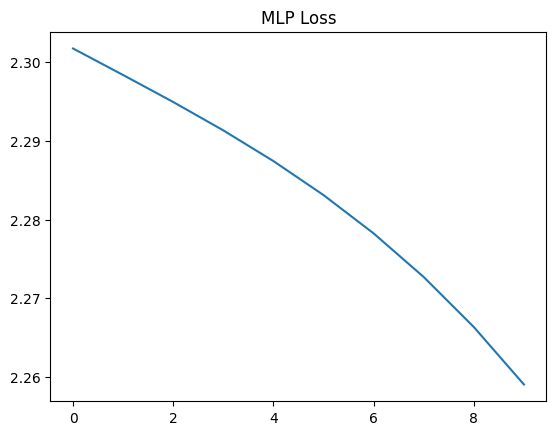

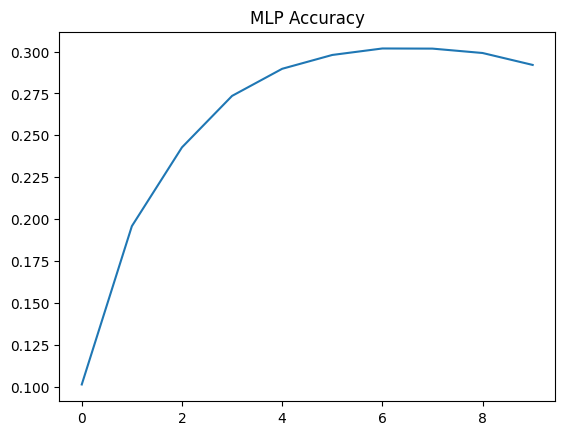

In [9]:
import matplotlib.pyplot as plt

plt.plot(losses); plt.title("MLP Loss"); plt.show()
plt.plot(accs); plt.title("MLP Accuracy"); plt.show()

In [ ]:
# 7. SHOW RECONSTRUCTIONS

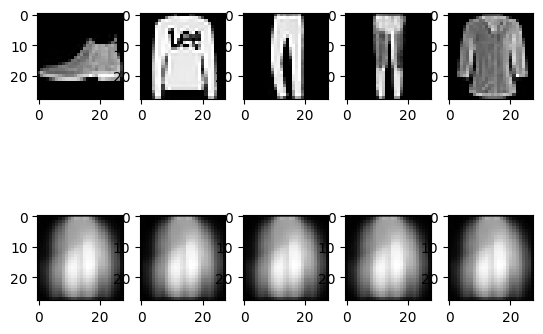

In [10]:
n=5
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")

    plt.subplot(2,n,n+i+1)
    plt.imshow(recon[i].reshape(28,28), cmap="gray")
plt.show()